In [1]:
# ===================================================================
# SWOT L3 Basic SSH Analysis — Andaman Sea Region
# ===================================================================

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import re
from datetime import datetime
from collections import defaultdict
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ===================================================================
# CONFIGURATION
# ===================================================================

# Base directory containing cycle folders (e.g., cycle_040, cycle_041, ...)
BASE_DIR = r"Y:\level 3 ocean basic files\Basic_filters"

# ───────────────────────────────────────────────────────────────────
# CYCLE SELECTION CONTROL
# ───────────────────────────────────────────────────────────────────
# Set PROCESS_ALL_CYCLES = True  → loops through ALL cycle_* folders
# Set PROCESS_ALL_CYCLES = False → processes ONLY the cycles listed below
PROCESS_ALL_CYCLES = False  # <-- Set to True or False as needed

# Manually specify cycle numbers when PROCESS_ALL_CYCLES = False
SPECIFIC_CYCLES = [40, 41]  # <-- Add/remove cycle numbers here

# Andaman Sea region bounds
LAT_BOUNDS = (-4.0, 31.0 )
LON_BOUNDS = (73.2, 107.0)

# Latitude extent: 31 to -4, longitude: 73.2 to 107
# ===================================================================
# AUTO-DISCOVER CYCLE FOLDERS
# ===================================================================
cycle_pattern = re.compile(r'^cycle_(\d+)$', re.IGNORECASE)
all_cycle_dirs = []

for entry in sorted(os.listdir(BASE_DIR)):
    full_path = os.path.join(BASE_DIR, entry)
    if os.path.isdir(full_path):
        m = cycle_pattern.match(entry)
        if m:
            cycle_num = int(m.group(1))
            all_cycle_dirs.append({'cycle_num': cycle_num, 'path': full_path, 'folder': entry})

print(f"Total cycle folders found: {len(all_cycle_dirs)}")
print(f"Cycles available: {[c['cycle_num'] for c in all_cycle_dirs]}")

# Filter based on user selection
if PROCESS_ALL_CYCLES:
    selected_cycles = all_cycle_dirs
    print(f"\n>>> Mode: PROCESS ALL CYCLES ({len(selected_cycles)} cycles)")
else:
    selected_cycles = [c for c in all_cycle_dirs if c['cycle_num'] in SPECIFIC_CYCLES]
    print(f"\n>>> Mode: SPECIFIC CYCLES ONLY → {SPECIFIC_CYCLES}")
    print(f"    Matched {len(selected_cycles)} of {len(SPECIFIC_CYCLES)} requested cycles")
    missing = set(SPECIFIC_CYCLES) - set(c['cycle_num'] for c in selected_cycles)
    if missing:
        print(f"    ⚠️ Not found: {sorted(missing)}")

print(f"\nCycles to process: {[c['cycle_num'] for c in selected_cycles]}")

# ===================================================================
# PARSE L3 BASIC FILENAMES
# ===================================================================
def parse_l3_filename(filepath):
    """
    Parse SWOT L3 Basic filename.
    Example: SWOT_L3_LR_SSH_Basic_040_005_20251012T021739_20251012T030905_v3.0.nc
    """
    basename = os.path.basename(filepath)
    pattern = r'SWOT_L3_LR_SSH_Basic_(\d{3})_(\d{3})_(\d{8}T\d{6})_(\d{8}T\d{6})_v(\d+\.\d+)\.nc'
    match = re.match(pattern, basename)
    
    if match:
        return {
            'filename': basename,
            'filepath': filepath,
            'cycle': int(match.group(1)),
            'pass_number': int(match.group(2)),
            'start_datetime': datetime.strptime(match.group(3), '%Y%m%dT%H%M%S'),
            'end_datetime': datetime.strptime(match.group(4), '%Y%m%dT%H%M%S'),
            'version': match.group(5),
        }
    return None

Total cycle folders found: 45
Cycles available: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45]

>>> Mode: SPECIFIC CYCLES ONLY → [40, 41]
    Matched 2 of 2 requested cycles

Cycles to process: [40, 41]


In [3]:
# ===================================================================
# INVESTIGATE A SAMPLE .nc FILE — Explore Structure & Variables
# ===================================================================
import netCDF4

# Pick the first file from the first selected cycle
sample_cycle = selected_cycles[0]
sample_nc_files = glob.glob(os.path.join(sample_cycle['path'], "*.nc"))
sample_file = sample_nc_files[0]

print(f"Investigating: {os.path.basename(sample_file)}")
print(f"From cycle folder: {sample_cycle['folder']}")
print(f"Full path: {sample_file}")

ds = netCDF4.Dataset(sample_file, 'r')

# ─── Global Attributes ───
print("\n" + "=" * 80)
print("  GLOBAL ATTRIBUTES")
print("=" * 80)
for attr in ds.ncattrs():
    val = ds.getncattr(attr)
    val_str = str(val)
    if len(val_str) > 120:
        val_str = val_str[:120] + "..."
    print(f"  {attr:<40} = {val_str}")

# ─── Dimensions ───
print("\n" + "=" * 80)
print("  DIMENSIONS")
print("=" * 80)
for dname, dim in ds.dimensions.items():
    print(f"  {dname:<30} size = {len(dim):<10} unlimited = {dim.isunlimited()}")

# ─── Groups (if any) ───
print("\n" + "=" * 80)
print("  GROUPS")
print("=" * 80)
if ds.groups:
    for gname in ds.groups:
        print(f"  /{gname}")
        grp = ds.groups[gname]
        for vname in grp.variables:
            print(f"    └─ {vname}")
else:
    print("  (No groups — all variables at root level)")

# ─── Variables — Detailed ───
print("\n" + "=" * 80)
print(f"  VARIABLES  ({len(ds.variables)} total)")
print("=" * 80)
for vname, var in ds.variables.items():
    dims = var.dimensions
    shape = var.shape
    dtype = var.dtype
    units = getattr(var, 'units', '—')
    long_name = getattr(var, 'long_name', '—')
    fill = getattr(var, '_FillValue', '—')
    comment = getattr(var, 'comment', '')
    
    print(f"\n  📌 {vname}")
    print(f"     dims      : {dims}")
    print(f"     shape     : {shape}")
    print(f"     dtype     : {dtype}")
    print(f"     units     : {units}")
    print(f"     long_name : {long_name}")
    print(f"     _FillValue: {fill}")
    if comment:
        comment_str = comment[:150] + "..." if len(comment) > 150 else comment
        print(f"     comment   : {comment_str}")
    
    # Quick stats for numeric variables (small preview)
    try:
        data = var[:]
        if hasattr(data, 'compressed'):
            data = data.compressed()  # remove masked values
        if len(data) > 0 and np.issubdtype(dtype, np.number):
            print(f"     min={np.nanmin(data):.6g}  max={np.nanmax(data):.6g}  "
                  f"mean={np.nanmean(data):.6g}  non-NaN count={np.sum(np.isfinite(data.astype(float)))}")
    except Exception:
        pass

# ─── Also open with xarray for a clean overview ───
print("\n" + "=" * 80)
print("  XARRAY OVERVIEW")
print("=" * 80)
ds_xr = xr.open_dataset(sample_file, engine='netcdf4')
print(ds_xr)
print("\n  Data variables list:")
for v in ds_xr.data_vars:
    print(f"    {v}: {ds_xr[v].dims} → {ds_xr[v].shape}")

ds_xr.close()
ds.close()
print("\n✅ Investigation complete!")

Investigating: SWOT_L3_LR_SSH_Basic_040_049_20251013T160120_20251013T165246_v3.0.nc
From cycle folder: cycle_040
Full path: Y:\level 3 ocean basic files\Basic_filters\cycle_040\SWOT_L3_LR_SSH_Basic_040_049_20251013T160120_20251013T165246_v3.0.nc

  GLOBAL ATTRIBUTES
  Conventions                              = CF-1.9
  Metadata_Conventions                     = Unidata Dataset Discovery v1.0
  cdm_data_type                            = Swath
  comment                                  = Sea Surface Height measured by Altimetry
  data_used                                = SWOT KaRIn L2_LR_SSH PGC0/PIC0/PIC2/PID0 (NASA/CNES). DOI associated: https://doi.org/10.24400/527896/a01-2023.015
  doi                                      = https://doi.org/10.24400/527896/A01-2023.017
  geospatial_lat_units                     = degrees_north
  geospatial_lon_units                     = degrees_east
  geospatial_vertical_max                  = 0
  geospatial_vertical_min                  = 0
  geosp

In [4]:
# ===================================================================
# FUNCTION: Load data from a single L3 Basic file
# ===================================================================
def load_l3_data(filepath):
    """
    Load latitude, longitude, and SSHA from a SWOT L3 Basic file.
    L3 files have NO groups — all data is at the root level.
    Returns flattened arrays of valid (non-fill) points.
    """
    ds = xr.open_dataset(filepath, engine='netcdf4')
    
    lat = ds['latitude'].values.astype(float).ravel()
    lon = ds['longitude'].values.astype(float).ravel()
    
    # Pick the best available SSHA variable
    if 'ssha_filtered' in ds:
        ssha = ds['ssha_filtered'].values.astype(float).ravel()
        ssha_var = 'ssha_filtered'
    elif 'ssha_unfiltered' in ds:
        ssha = ds['ssha_unfiltered'].values.astype(float).ravel()
        ssha_var = 'ssha_unfiltered'
    else:
        ds.close()
        raise ValueError(f"No SSHA variable found. Available: {list(ds.variables)}")
    
    ds.close()
    
    # Remove fill values (huge values) and NaNs
    FILL_THRESH = 1e10
    valid = (np.isfinite(lat) & np.isfinite(lon) & np.isfinite(ssha) &
             (np.abs(lat) < FILL_THRESH) & (np.abs(lon) < FILL_THRESH) &
             (np.abs(ssha) < FILL_THRESH))
    
    return lat[valid], lon[valid], ssha[valid], ssha_var


# ===================================================================
# FUNCTION: Plot passes on Andaman Sea map
# ===================================================================
def plot_passes(file_list, title_label, lat_bounds, lon_bounds, save_name):
    """
    Plot all passes from file_list on a single Andaman Sea map.
    Returns list of pass numbers that have data in the region.
    """
    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    
    ax.set_extent([lon_bounds[0], lon_bounds[1], lat_bounds[0], lat_bounds[1]],
                  crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    
    passes_plotted = []
    passes_no_data = []
    passes_error = []
    sc = None
    total_points = 0
    
    for f in file_list:
        pid = f['pass_number']
        try:
            lat, lon, ssha, ssha_var = load_l3_data(f['filepath'])
            print(f"    Pass {pid:03d} → using variable: {ssha_var}")
            
            # Filter to Andaman Sea region
            in_region = ((lat >= lat_bounds[0]) & (lat <= lat_bounds[1]) &
                         (lon >= lon_bounds[0]) & (lon <= lon_bounds[1]))
            n_pts = np.sum(in_region)
            
            if n_pts > 0:
                sc = ax.scatter(lon[in_region], lat[in_region], c=ssha[in_region],
                               cmap='RdBu_r', s=0.5, alpha=0.8,
                               vmin=-0.5, vmax=0.5,
                               transform=ccrs.PlateCarree())
                passes_plotted.append(pid)
                total_points += n_pts
            else:
                passes_no_data.append(pid)
                
        except Exception as e:
            passes_error.append((pid, str(e)[:60]))
    
    # Colorbar
    if sc is not None:
        cbar = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
        cbar.set_label('SSHA (m)', fontsize=12)
    
    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    
    # Pass list annotation
    passes_str = ', '.join(str(p) for p in sorted(passes_plotted))
    ax.text(1.02, 0.98, f'Passes in region ({len(passes_plotted)}):\n{passes_str}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    
    ax.set_title(f'SWOT L3 Basic — {title_label}\n'
                 f'Andaman Sea ({lat_bounds[0]}°–{lat_bounds[1]}°N, {lon_bounds[0]}°–{lon_bounds[1]}°E)\n'
                 f'{len(passes_plotted)} passes | {total_points:,} points',
                 fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(save_name, dpi=200, bbox_inches='tight')
    plt.show()
    
    # Summary
    print(f"\n{'='*70}")
    print(f"  {title_label} — SUMMARY")
    print(f"{'='*70}")
    print(f"  Total files attempted : {len(file_list)}")
    print(f"  Passes with data in region : {len(passes_plotted)}")
    print(f"  Passes outside region      : {len(passes_no_data)}")
    print(f"  Passes with errors         : {len(passes_error)}")
    print(f"  Total points plotted       : {total_points:,}")
    print(f"\n  ✓ Passes plotted: {sorted(passes_plotted)}")
    if passes_no_data:
        print(f"  ✗ No data in region: {sorted(passes_no_data)}")
    if passes_error:
        for pid, err in passes_error:
            print(f"  ⚠️ Pass {pid}: {err}")
    print(f"{'='*70}")
    
    return passes_plotted, passes_no_data


####################################################################################################
#  CYCLE 040  —  cycle_040
####################################################################################################

  Total .nc files found: 17
  Successfully parsed: 17 files
  Unique passes: 17  |  Forward: 9  |  Backward: 8
  Date range: 2025-10-13 → 2025-10-31 (17 days)

  ────────────────────────────────────────────────────────────────────────────────
  FORWARD PASSES (ODD) — Cycle 040  |  9 files
  ────────────────────────────────────────────────────────────────────────────────
    Pass 049 → using variable: ssha_filtered
    Pass 077 → using variable: ssha_filtered
    Pass 105 → using variable: ssha_filtered
    Pass 133 → using variable: ssha_filtered
    Pass 161 → using variable: ssha_filtered
    Pass 355 → using variable: ssha_filtered
    Pass 383 → using variable: ssha_filtered
    Pass 411 → using variable: ssha_filtered
    Pass 439 → using variable: ssha_

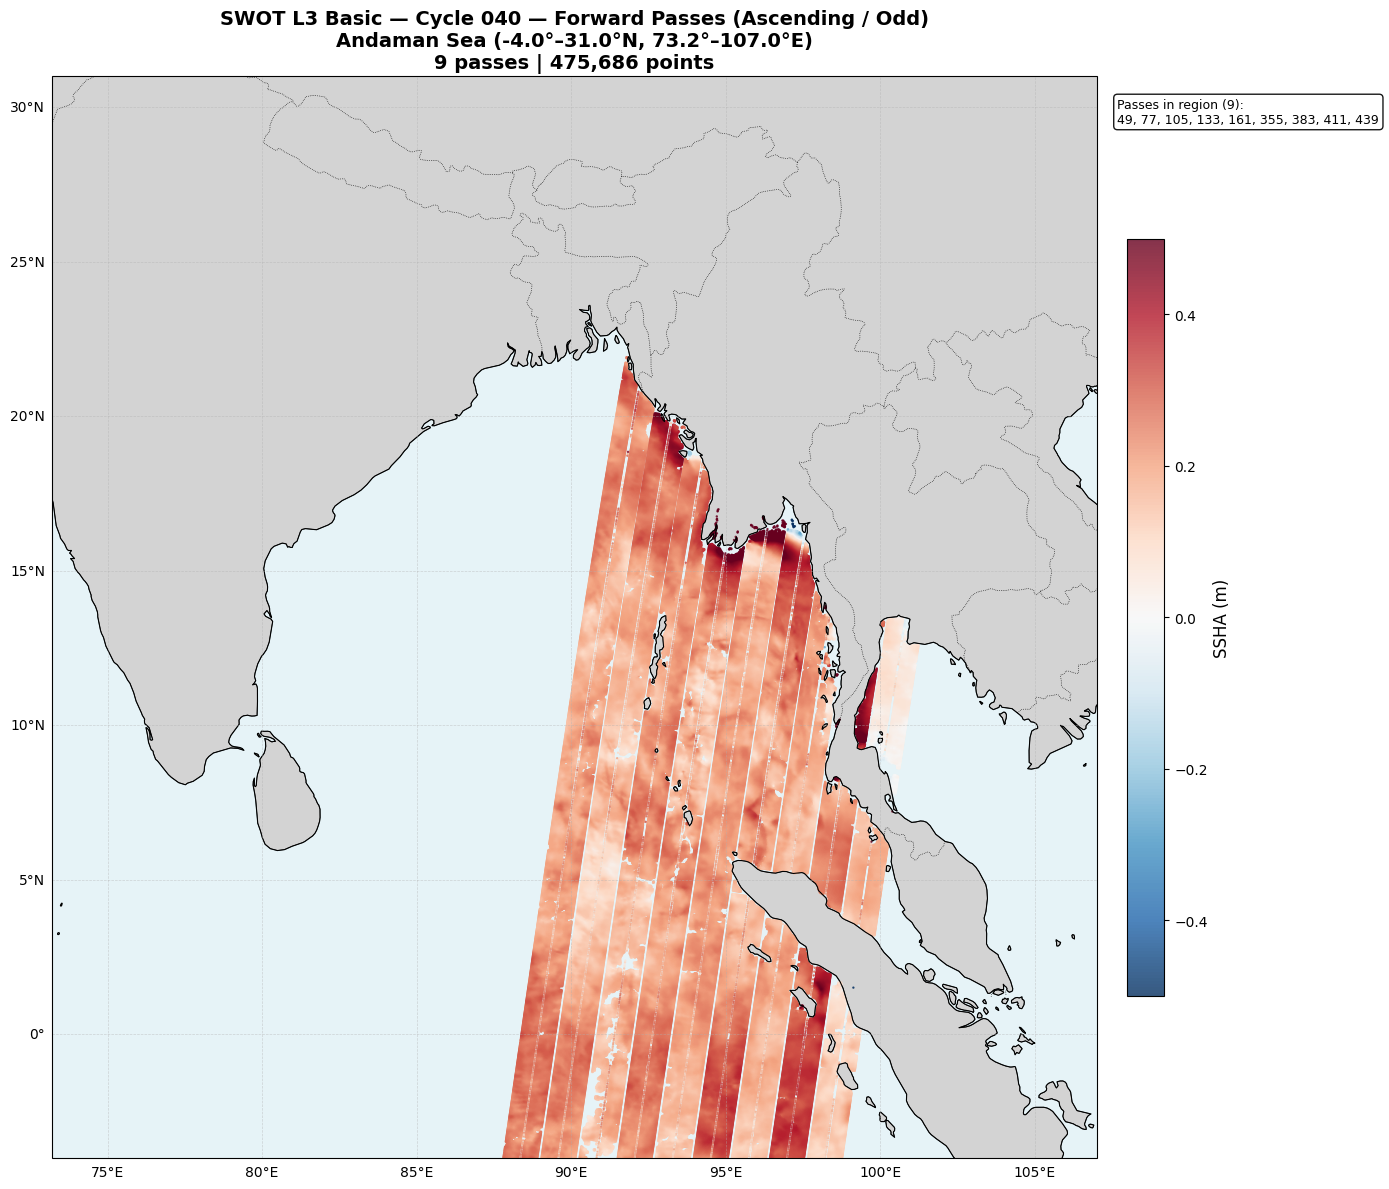


  Cycle 040 — Forward Passes (Ascending / Odd) — SUMMARY
  Total files attempted : 9
  Passes with data in region : 9
  Passes outside region      : 0
  Passes with errors         : 0
  Total points plotted       : 475,686

  ✓ Passes plotted: [49, 77, 105, 133, 161, 355, 383, 411, 439]

  ────────────────────────────────────────────────────────────────────────────────
  BACKWARD PASSES (EVEN) — Cycle 040  |  8 files
  ────────────────────────────────────────────────────────────────────────────────
    Pass 174 → using variable: ssha_filtered
    Pass 202 → using variable: ssha_filtered
    Pass 230 → using variable: ssha_filtered
    Pass 258 → using variable: ssha_filtered
    Pass 452 → using variable: ssha_filtered
    Pass 480 → using variable: ssha_filtered
    Pass 508 → using variable: ssha_filtered
    Pass 536 → using variable: ssha_filtered


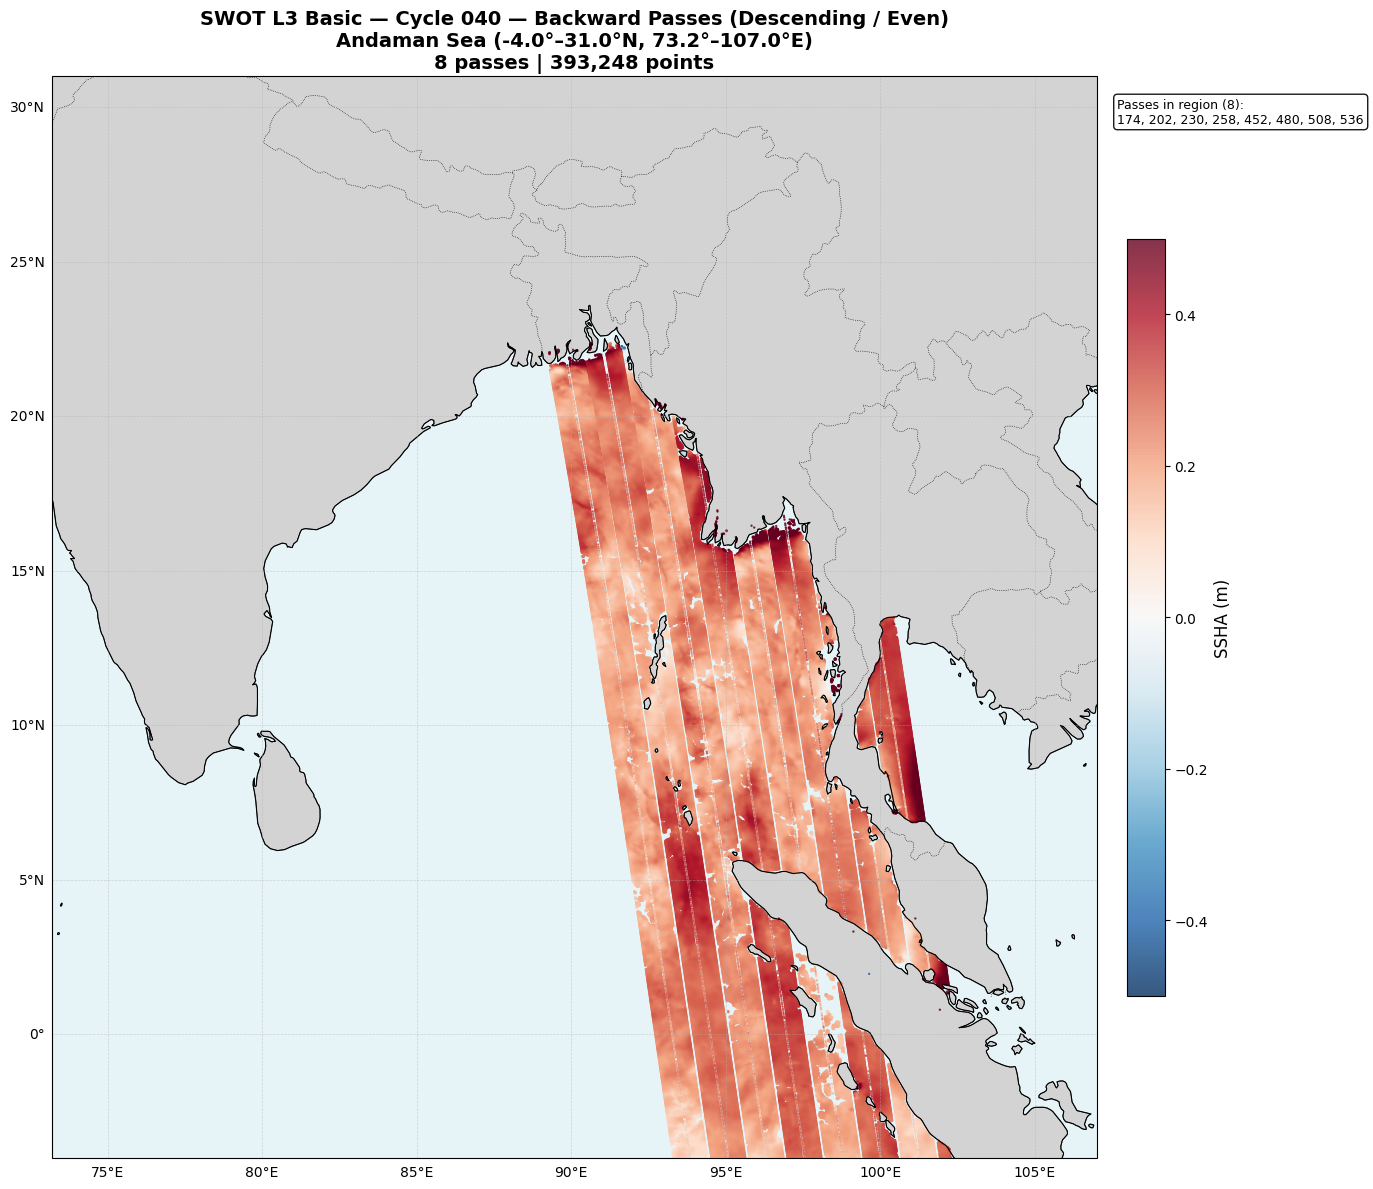


  Cycle 040 — Backward Passes (Descending / Even) — SUMMARY
  Total files attempted : 8
  Passes with data in region : 8
  Passes outside region      : 0
  Passes with errors         : 0
  Total points plotted       : 393,248

  ✓ Passes plotted: [174, 202, 230, 258, 452, 480, 508, 536]

  ✅ Cycle 040 complete — Forward: 9 passes | Backward: 8 passes

####################################################################################################
#  CYCLE 041  —  cycle_041
####################################################################################################

  Total .nc files found: 17
  Successfully parsed: 17 files
  Unique passes: 17  |  Forward: 9  |  Backward: 8
  Date range: 2025-11-03 → 2025-11-20 (17 days)

  ────────────────────────────────────────────────────────────────────────────────
  FORWARD PASSES (ODD) — Cycle 041  |  9 files
  ────────────────────────────────────────────────────────────────────────────────
    Pass 049 → using variable: ssha_filter

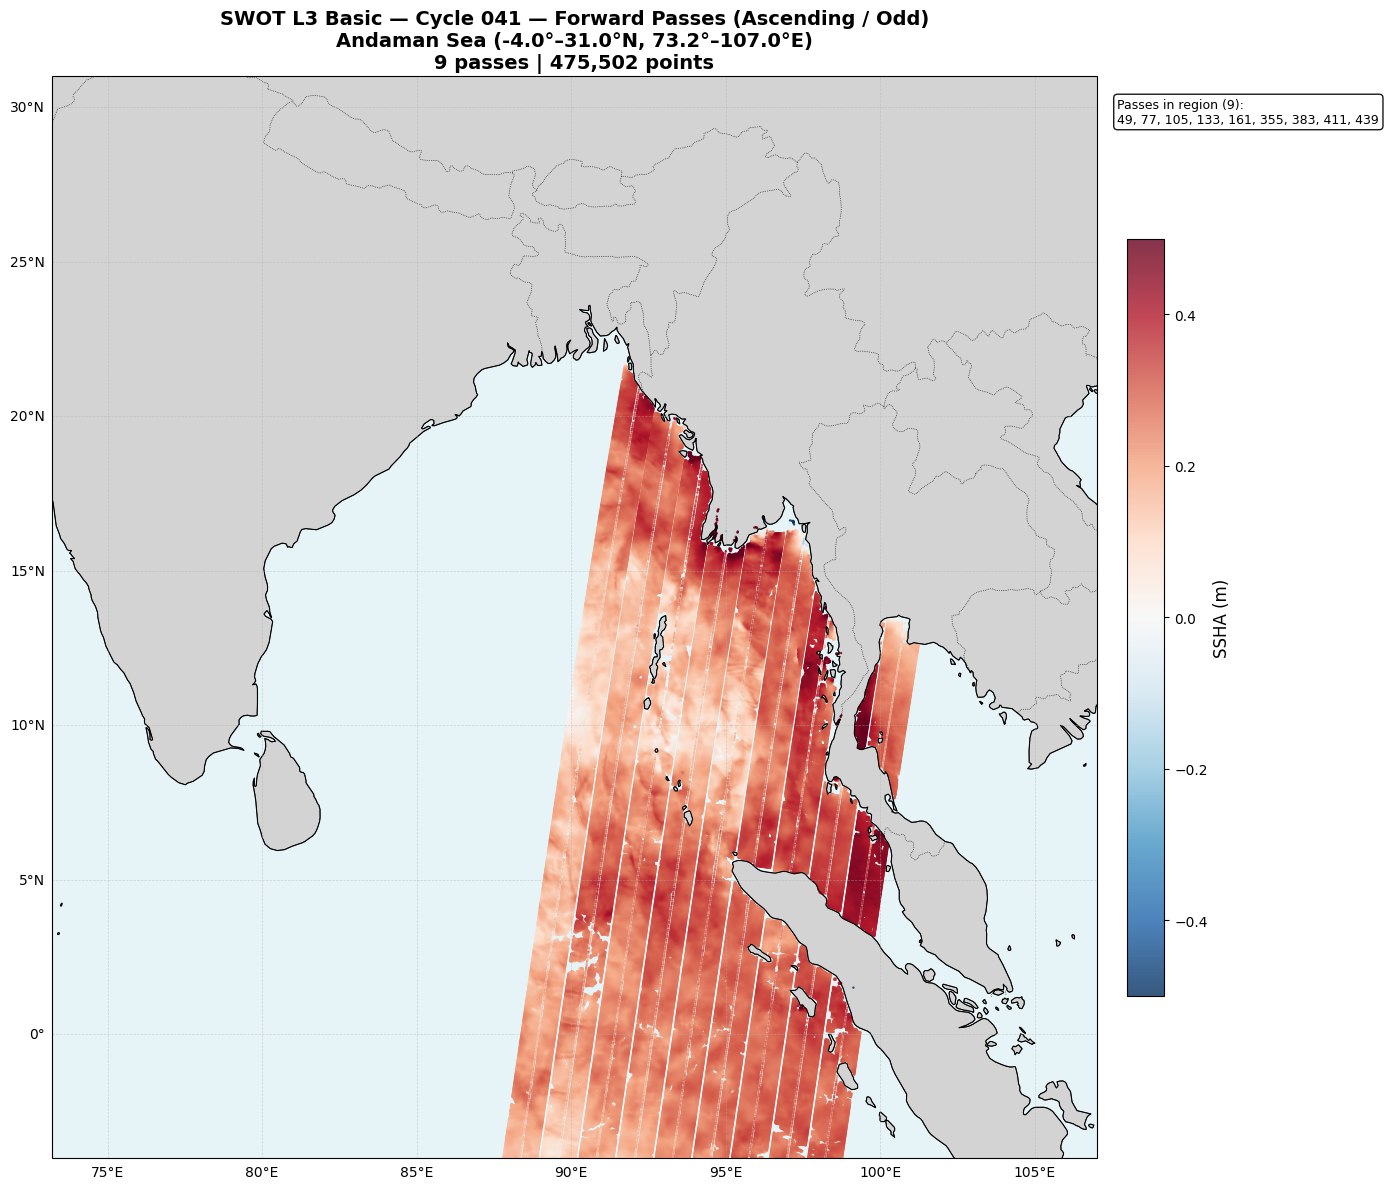


  Cycle 041 — Forward Passes (Ascending / Odd) — SUMMARY
  Total files attempted : 9
  Passes with data in region : 9
  Passes outside region      : 0
  Passes with errors         : 0
  Total points plotted       : 475,502

  ✓ Passes plotted: [49, 77, 105, 133, 161, 355, 383, 411, 439]

  ────────────────────────────────────────────────────────────────────────────────
  BACKWARD PASSES (EVEN) — Cycle 041  |  8 files
  ────────────────────────────────────────────────────────────────────────────────
    Pass 174 → using variable: ssha_filtered
    Pass 202 → using variable: ssha_filtered
    Pass 230 → using variable: ssha_filtered
    Pass 258 → using variable: ssha_filtered
    Pass 452 → using variable: ssha_filtered
    Pass 480 → using variable: ssha_filtered
    Pass 508 → using variable: ssha_filtered
    Pass 536 → using variable: ssha_filtered


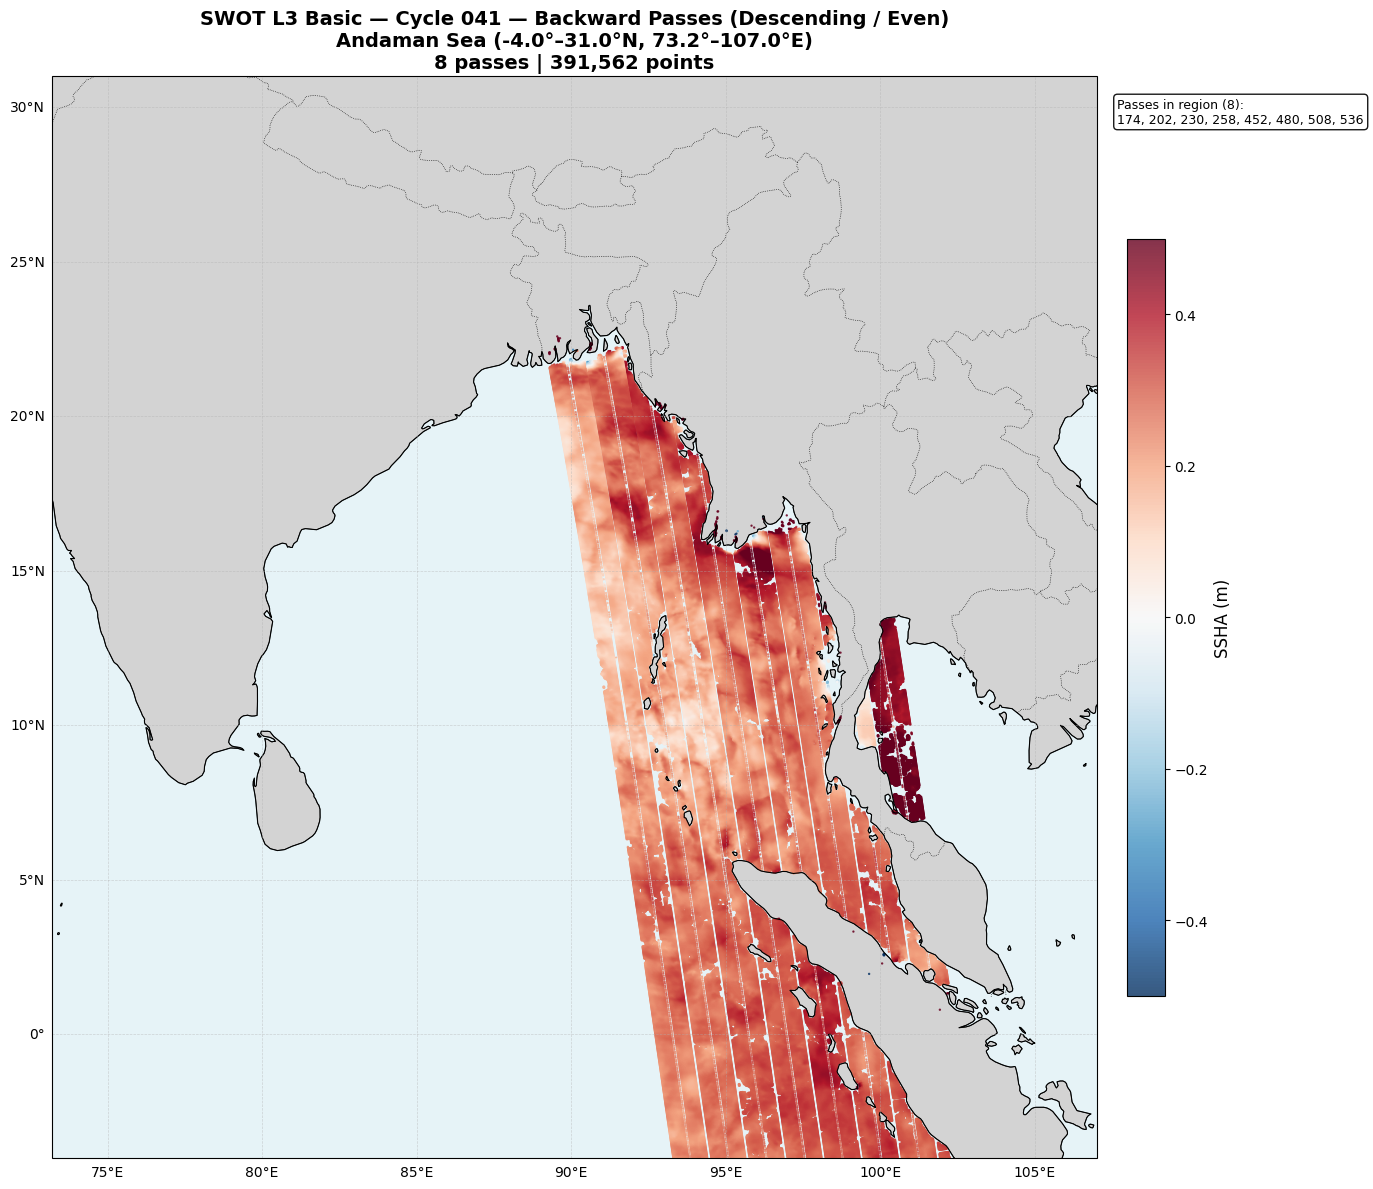


  Cycle 041 — Backward Passes (Descending / Even) — SUMMARY
  Total files attempted : 8
  Passes with data in region : 8
  Passes outside region      : 0
  Passes with errors         : 0
  Total points plotted       : 391,562

  ✓ Passes plotted: [174, 202, 230, 258, 452, 480, 508, 536]

  ✅ Cycle 041 complete — Forward: 9 passes | Backward: 8 passes

  ALL CYCLES PROCESSED!


In [5]:
# ===================================================================
# LOOP THROUGH ALL SELECTED CYCLES — Plot Forward & Backward Passes
# ===================================================================

# Store results for grand summary
all_results = {}

for cycle_info in selected_cycles:
    cycle_num = cycle_info['cycle_num']
    cycle_dir = cycle_info['path']
    cycle_folder = cycle_info['folder']
    
    print("\n" + "#" * 100)
    print(f"#  CYCLE {cycle_num:03d}  —  {cycle_folder}")
    print("#" * 100)
    
    # ------ Scan and parse files for this cycle ------
    nc_files = glob.glob(os.path.join(cycle_dir, "*.nc"))
    print(f"\n  Total .nc files found: {len(nc_files)}")
    
    if not nc_files:
        print(f"  ⚠️ No .nc files in {cycle_dir}, skipping...")
        all_results[cycle_num] = {'fwd_plotted': [], 'fwd_no_data': [],
                                   'bwd_plotted': [], 'bwd_no_data': [], 'skipped': True}
        continue
    
    parsed = [parse_l3_filename(f) for f in nc_files]
    parsed = [p for p in parsed if p is not None]
    print(f"  Successfully parsed: {len(parsed)} files")
    
    if not parsed:
        print(f"  ⚠️ No valid L3 Basic files parsed, skipping...")
        all_results[cycle_num] = {'fwd_plotted': [], 'fwd_no_data': [],
                                   'bwd_plotted': [], 'bwd_no_data': [], 'skipped': True}
        continue
    
    # Keep unique granules (highest version if duplicates)
    granule_map = defaultdict(list)
    for p in parsed:
        key = (p['cycle'], p['pass_number'], p['start_datetime'].strftime('%Y%m%dT%H%M%S'))
        granule_map[key].append(p)
    
    files_info = [max(files, key=lambda x: x['version']) for files in granule_map.values()]
    files_info.sort(key=lambda x: x['pass_number'])
    
    forward_files = [f for f in files_info if f['pass_number'] % 2 == 1]
    backward_files = [f for f in files_info if f['pass_number'] % 2 == 0]
    
    print(f"  Unique passes: {len(files_info)}  |  Forward: {len(forward_files)}  |  Backward: {len(backward_files)}")
    
    # ------ Date/Time info ------
    dates = sorted(set(f['start_datetime'] for f in files_info))
    print(f"  Date range: {min(dates).strftime('%Y-%m-%d')} → {max(dates).strftime('%Y-%m-%d')} ({(max(dates)-min(dates)).days} days)")
    
    # ------ PLOT FORWARD PASSES ------
    print(f"\n  {'─'*80}")
    print(f"  FORWARD PASSES (ODD) — Cycle {cycle_num:03d}  |  {len(forward_files)} files")
    print(f"  {'─'*80}")
    
    fwd_plotted, fwd_no_data = plot_passes(
        forward_files,
        title_label=f"Cycle {cycle_num:03d} — Forward Passes (Ascending / Odd)",
        lat_bounds=LAT_BOUNDS,
        lon_bounds=LON_BOUNDS,
        save_name=f"andaman_cycle{cycle_num:03d}_forward_passes.png"
    )
    
    # ------ PLOT BACKWARD PASSES ------
    print(f"\n  {'─'*80}")
    print(f"  BACKWARD PASSES (EVEN) — Cycle {cycle_num:03d}  |  {len(backward_files)} files")
    print(f"  {'─'*80}")
    
    bwd_plotted, bwd_no_data = plot_passes(
        backward_files,
        title_label=f"Cycle {cycle_num:03d} — Backward Passes (Descending / Even)",
        lat_bounds=LAT_BOUNDS,
        lon_bounds=LON_BOUNDS,
        save_name=f"andaman_cycle{cycle_num:03d}_backward_passes.png"
    )
    
    # ------ Per-cycle summary ------
    all_results[cycle_num] = {
        'fwd_plotted': fwd_plotted, 'fwd_no_data': fwd_no_data,
        'bwd_plotted': bwd_plotted, 'bwd_no_data': bwd_no_data,
        'total_files': len(files_info), 'skipped': False
    }
    
    print(f"\n  ✅ Cycle {cycle_num:03d} complete — "
          f"Forward: {len(fwd_plotted)} passes | Backward: {len(bwd_plotted)} passes")

print("\n" + "=" * 100)
print("  ALL CYCLES PROCESSED!")
print("=" * 100)

In [6]:
# ===================================================================
# GRAND SUMMARY — ALL CYCLES
# ===================================================================
print("\n" + "=" * 100)
print("  GRAND SUMMARY — ALL CYCLES — ANDAMAN SEA REGION COVERAGE")
print("=" * 100)

total_fwd = 0
total_bwd = 0
total_fwd_no = 0
total_bwd_no = 0

for cycle_num in sorted(all_results.keys()):
    res = all_results[cycle_num]
    if res['skipped']:
        print(f"\n  Cycle {cycle_num:03d}: ⚠️ SKIPPED (no valid files)")
        continue
    
    nf = len(res['fwd_plotted'])
    nb = len(res['bwd_plotted'])
    nf_no = len(res['fwd_no_data'])
    nb_no = len(res['bwd_no_data'])
    total_fwd += nf
    total_bwd += nb
    total_fwd_no += nf_no
    total_bwd_no += nb_no
    
    print(f"\n  Cycle {cycle_num:03d}:")
    print(f"    Forward  — ✓ In region: {nf:3d} passes  |  ✗ No data: {nf_no:3d} passes")
    print(f"    Backward — ✓ In region: {nb:3d} passes  |  ✗ No data: {nb_no:3d} passes")
    print(f"    Passes plotted: {sorted(res['fwd_plotted'] + res['bwd_plotted'])}")

print(f"\n{'─'*100}")
print(f"  TOTALS ACROSS {len([c for c in all_results.values() if not c['skipped']])} CYCLE(S):")
print(f"    Forward passes with data  : {total_fwd}")
print(f"    Backward passes with data : {total_bwd}")
print(f"    Total passes with data    : {total_fwd + total_bwd}")
print(f"    Forward passes no data    : {total_fwd_no}")
print(f"    Backward passes no data   : {total_bwd_no}")
mode_str = "ALL CYCLES" if PROCESS_ALL_CYCLES else f"SPECIFIC CYCLES: {SPECIFIC_CYCLES}"
print(f"\n    Mode: {mode_str}")
print("=" * 100)


  GRAND SUMMARY — ALL CYCLES — ANDAMAN SEA REGION COVERAGE

  Cycle 040:
    Forward  — ✓ In region:   9 passes  |  ✗ No data:   0 passes
    Backward — ✓ In region:   8 passes  |  ✗ No data:   0 passes
    Passes plotted: [49, 77, 105, 133, 161, 174, 202, 230, 258, 355, 383, 411, 439, 452, 480, 508, 536]

  Cycle 041:
    Forward  — ✓ In region:   9 passes  |  ✗ No data:   0 passes
    Backward — ✓ In region:   8 passes  |  ✗ No data:   0 passes
    Passes plotted: [49, 77, 105, 133, 161, 174, 202, 230, 258, 355, 383, 411, 439, 452, 480, 508, 536]

────────────────────────────────────────────────────────────────────────────────────────────────────
  TOTALS ACROSS 2 CYCLE(S):
    Forward passes with data  : 18
    Backward passes with data : 16
    Total passes with data    : 34
    Forward passes no data    : 0
    Backward passes no data   : 0

    Mode: SPECIFIC CYCLES: [40, 41]
